# Case Study 2 — The G10 FX Carry Trade

**Environment:** `quant-ts` conda env (`environment.yml`). Data are downloaded from FRED and Yahoo Finance by the Section 1 cache functions; the as-of date of the pull is printed below.

**Conventions used throughout (every currency, every section):**

- **Numeraire:** USD. Every spot rate $S_{i,t}$ is stored as **USD per 1 unit of currency $i$**. A *long* position in currency $i$ is long $i$ / short USD, so $\Delta s_{i,t} > 0$ means currency $i$ appreciated and the long earns.
- **Returns:** daily log returns in percent.
- **Accrual:** calendar-day compounding, $\big[(1+i/100)^{n/365}-1\big]\times 100$, where $n$ is the number of calendar days between observations (weekends/holidays accrue).

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
RATES_CACHE = DATA_DIR / "cs2cb_rates.csv"
SPOT_CACHE = DATA_DIR / "cs2cb_spot.csv"

START = "2010-01-01"
TODAY = pd.Timestamp.today().normalize()
CCYS = ["EUR", "JPY", "GBP", "CHF", "CAD", "AUD", "NZD", "SEK", "NOK"]  # non-USD
print("As-of date:", TODAY.date())

As-of date: 2026-09-30


## Section 1 — Data Pipeline: Building the G10 Universe

### Section 1.1 — Short-Term Interest Rates

Each series ID below was checked against FRED (`fredgraph.csv?id=...`) for existence, monthly frequency, and whether it is still being updated. The last-observation table printed below the fetch is that check, reproduced on every run.

| Ccy | FRED series | Description | Why |
|---|---|---|---|
| USD | `IRSTCI01USM156N` | Call money / interbank, monthly | Current |
| JPY | `IRSTCI01JPM156N` | Call money / interbank, monthly | Current (lecture series) |
| GBP | `IRSTCI01GBM156N` | Call money / interbank, monthly | Current |
| CAD | `IRSTCI01CAM156N` | Call money / interbank, monthly | Current (monthly call-money series does exist for Canada) |
| AUD | `IRSTCI01AUM156N` | Call money / interbank, monthly | Current (lecture series) |
| NOK | `IRSTCI01NOM156N` | Call money / interbank, monthly | Current |
| CHF | `IR3TIB01CHM156N` | **3-month** interbank, monthly | **Substitution:** `IRSTCI01CHM156N` stops in 2024-03 |
| NZD | `IR3TIB01NZM156N` | **3-month** interbank, monthly | **Substitution:** `IRSTCI01NZM156N` stops in 2024-12 |
| SEK | `IR3TIB01SEM156N` | **3-month** interbank, monthly | **Substitution:** `IRSTCI01SEM156N` stops in 2020-10 |
| EUR | `IRSTCI01EZM156N` + `ECBESTRVOLWGTTRMDMNRT` | Euro-area call money, then €STR (daily → monthly mean) | **Splice:** both OECD euro-area series (`IRSTCI01EZ`, `IR3TIB01EZ`) stop in 2026-01; €STR (the ECB's official overnight rate) fills the months after the OECD series ends |

Caveat: CHF, NZD and SEK use a 3-month rate while the rest use overnight. Tenor spreads are small relative to cross-country differentials (typically < 25 bp), but they slightly bias those three currencies' carry. All values are annualized percent. Only **complete** months are kept, so the partial current month of €STR is not used.

In [2]:
FRED_SERIES = {
    "USD": "IRSTCI01USM156N", "JPY": "IRSTCI01JPM156N", "GBP": "IRSTCI01GBM156N",
    "CAD": "IRSTCI01CAM156N", "AUD": "IRSTCI01AUM156N", "NOK": "IRSTCI01NOM156N",
    "CHF": "IR3TIB01CHM156N", "NZD": "IR3TIB01NZM156N", "SEK": "IR3TIB01SEM156N",
    "EUR": "IRSTCI01EZM156N",
}
ESTR_SERIES = "ECBESTRVOLWGTTRMDMNRT"


def fred(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    return pd.read_csv(url, index_col=0, parse_dates=True, na_values=".").iloc[:, 0]


def fetch_rates():
    rates = pd.DataFrame({ccy: fred(sid) for ccy, sid in FRED_SERIES.items()})
    # EUR splice: OECD series through its last observation, then monthly-mean ESTR
    estr = fred(ESTR_SERIES).resample("MS").mean()
    eur_end = rates["EUR"].last_valid_index()
    rates["EUR"] = rates["EUR"].combine_first(estr[estr.index > eur_end])
    this_month = TODAY.to_period("M").to_timestamp()
    return rates[rates.index < this_month]  # complete months only

### Section 1.2 — Spot FX Rates

All nine pairs are pulled from Yahoo using the lecture's ticker convention. Direct quotes (`XXXUSD=X`, USD per XXX) are used as-is; indirect quotes (`USDXXX=X`, XXX per USD) are **inverted** so every column is USD per unit of foreign currency. `AUDJPY=X` (JPY per AUD) is also pulled for the single-pair comparison.

Yahoo columns are selected **by ticker name**. `lectures/fetch_data.py` instead relabels `yf.download(...)["Close"].columns` in request order, but Yahoo returns them sorted alphabetically. As a result, the lecture's `fx_rates.csv` column labelled `AUDJPY` actually contains EURUSD (1.44 in Jan 2010), and the one labelled `AUDUSD` contains AUDJPY (83.45). This is the base/quote mix-up the prompt warns about, and it is not carried over here.

In [3]:
DIRECT = {"EUR": "EURUSD=X", "GBP": "GBPUSD=X", "AUD": "AUDUSD=X", "NZD": "NZDUSD=X"}
INDIRECT = {"JPY": "USDJPY=X", "CHF": "USDCHF=X", "CAD": "USDCAD=X",
            "SEK": "USDSEK=X", "NOK": "USDNOK=X"}
CROSS = {"AUDJPY": "AUDJPY=X"}


def fetch_spot():
    tickers = list(DIRECT.values()) + list(INDIRECT.values()) + list(CROSS.values())
    px = yf.download(tickers, start=START, end=TODAY, auto_adjust=True,
                     progress=False)["Close"]
    px = px[px.index < TODAY]  # drop today's incomplete bar (Yahoo FX can return it)
    spot = pd.DataFrame(index=px.index)
    for ccy, tk in DIRECT.items():
        spot[ccy] = px[tk]            # USD per ccy
    for ccy, tk in INDIRECT.items():
        spot[ccy] = 1.0 / px[tk]      # invert ccy-per-USD -> USD per ccy
    for name, tk in CROSS.items():
        spot[name] = px[tk]           # JPY per AUD
    return spot[CCYS + list(CROSS)]

### Section 1.3 — The Cache

**Invalidation logic.** `load_cached(path, fetch_fn, expected_latest)` reads the CSV if it exists and compares its latest date with the most recent date the source *should* have:

- **Spot (Yahoo, daily):** the most recent business day before today (today's bar is incomplete and excluded).
- **Rates (FRED, monthly):** the first of the previous month, since OECD monthly averages appear with about a one-month lag.

If the file is missing, or its latest date is earlier than `expected_latest`, the full history is re-downloaded (which also picks up any revisions) and the file is overwritten. Otherwise the file is read from disk and nothing is requested from the network. If a source is late publishing, the check fails and the notebook re-downloads on each run until the data arrive. It never silently uses data older than expected. Paths are relative to the notebook (`data/`), so the cache works on any machine and a grader with no cache simply triggers a download.

In [4]:
def load_cached(path, fetch_fn, expected_latest):
    if path.exists():
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        if df.index.max() >= expected_latest:
            print(f"{path.name}: cache hit (through {df.index.max().date()})")
            return df
        print(f"{path.name}: stale (through {df.index.max().date()} < "
              f"{expected_latest.date()}), re-downloading")
    else:
        print(f"{path.name}: no cache, downloading")
    df = fetch_fn()
    df.to_csv(path)
    return df


spot_expected = TODAY - pd.offsets.BDay(1)
rates_expected = (TODAY - pd.offsets.MonthBegin(2)).normalize()
if TODAY.day == 1:  # MonthBegin(2) on the 1st steps back one month too far
    rates_expected += pd.offsets.MonthBegin(1)

rates_m = load_cached(RATES_CACHE, fetch_rates, rates_expected)
spot_raw = load_cached(SPOT_CACHE, fetch_spot, spot_expected)

# Verification table: coverage of each rate series
pd.DataFrame({
    "series": {c: FRED_SERIES[c] + (" + ESTR" if c == "EUR" else "") for c in rates_m},
    "first": rates_m.apply(lambda s: s.first_valid_index().date()),
    "last": rates_m.apply(lambda s: s.last_valid_index().date()),
    "latest (%)": rates_m.apply(lambda s: s.dropna().iloc[-1]).round(3),
})

cs2cb_rates.csv: cache hit (through 2026-08-01)
cs2cb_spot.csv: cache hit (through 2026-09-29)


,series,first,last,latest (%)
USD,IRSTCI01USM156N,1954-07-01,2026-08-01,3.630
JPY,IRSTCI01JPM156N,1985-07-01,2026-08-01,0.977
GBP,IRSTCI01GBM156N,1978-01-01,2026-08-01,3.731
CAD,IRSTCI01CAM156N,1975-01-01,2026-08-01,2.250
AUD,IRSTCI01AUM156N,1990-08-01,2026-08-01,4.350
NOK,IRSTCI01NOM156N,1982-01-01,2026-08-01,4.250
CHF,IR3TIB01CHM156N,1999-07-01,2026-08-01,-0.045
NZD,IR3TIB01NZM156N,1973-12-01,2026-08-01,2.980
SEK,IR3TIB01SEM156N,1982-01-01,2026-08-01,1.968
EUR,IRSTCI01EZM156N + ESTR,1994-01-01,2026-08-01,2.187


In [5]:
# Base/quote check: AUDUSD / JPYUSD should reproduce Yahoo's AUDJPY cross
implied = spot_raw["AUD"] / spot_raw["JPY"]
print("Median |implied / quoted AUDJPY - 1|:",
      f"{(implied / spot_raw['AUDJPY'] - 1).abs().median():.2e}")

Median |implied / quoted AUDJPY - 1|: 1.68e-04


### Section 1.4 — Constructing Per-Currency Carry P&L

For a long position in currency $i$ funded in USD, the daily carry P&L (in %) from $t-1$ to $t$ is

$$
z_{i,t} = 100\,\ln\frac{S_{i,t}}{S_{i,t-1}} + A(i_{i,t-1}, n_t) - A(i_{\text{USD},t-1}, n_t),
\qquad A(i, n) = 100\left[(1+i/100)^{n/365} - 1\right],
$$

where $n_t$ is the number of calendar days between $t-1$ and $t$. The AUD/JPY series uses the same formula with AUD as the long leg and JPY as the funding leg.

**Rate timing.** Each monthly value is forward-filled across the days of its month, and interest over $(t-1, t]$ accrues at the rate in effect on $t-1$ (the day the position is held). Days after the last published month (currently the in-progress month) accrue at the last available monthly rate.

**NaN handling (explicit):**

1. **Bad ticks:** a price is set to NaN if its log return is above 5% in absolute value *and* the next day's return reverses it by more than 5% (a one-day spike that immediately reverts). This catches Yahoo errors such as NOK on 2020-03-20, and leaves real shocks that persist, such as CHF on 2015-01-15/16 and GBP on 2016-06-24/27. Flagged prices are printed.
2. Spot rows where **any** of the ten series is missing (including flagged ticks) are dropped *before* differencing, so every return in a given row covers the same interval across currencies.
3. The first row (no prior price) is dropped.
4. All rate series start before 2010, so forward-filled rates have no NaNs on the spot index; this is asserted.

In [6]:
def accrued_pct(rate_pct, n_days):
    return ((1 + rate_pct / 100) ** (n_days / 365) - 1) * 100


def carry_pnl(spot, rate_long, rate_fund):
    # spot: price of the long currency in units of the funding currency
    spot_ret = np.log(spot).diff() * 100
    n_days = spot.index.to_series().diff().dt.days
    rl = rate_long.reindex(spot.index, method="ffill").shift(1)
    rf = rate_fund.reindex(spot.index, method="ffill").shift(1)
    return spot_ret + accrued_pct(rl, n_days) - accrued_pct(rf, n_days)


def flag_bad_ticks(px, thresh=5.0):
    r = np.log(px).diff() * 100
    nxt = r.shift(-1)
    return (r.abs() > thresh) & (nxt.abs() > thresh) & (np.sign(r) != np.sign(nxt))


bad = flag_bad_ticks(spot_raw.dropna(how="any"))
print("Flagged bad ticks:", [(c, d.date()) for c in bad for d in bad.index[bad[c]]])
spot = spot_raw.mask(bad.reindex(spot_raw.index, fill_value=False)).dropna(how="any")
print(f"Spot rows: {len(spot_raw)} raw, {len(spot)} after dropping rows with any "
      f"missing currency or a flagged tick ({len(spot_raw) - len(spot)} dropped)")

carry = pd.DataFrame({c: carry_pnl(spot[c], rates_m[c], rates_m["USD"]) for c in CCYS})
carry["AUDJPY"] = carry_pnl(spot["AUDJPY"], rates_m["AUD"], rates_m["JPY"])
carry = carry.iloc[1:]  # first row has no prior price
assert carry.notna().all().all(), "unexpected NaN in carry P&L"

# daily rate differential vs USD (annualized %), aligned to the carry index; used later
rate_diff = pd.DataFrame({c: (rates_m[c] - rates_m["USD"]) for c in CCYS})

print(f"Carry P&L: {carry.shape[0]} days x {carry.shape[1]} series, "
      f"{carry.index[0].date()} to {carry.index[-1].date()}")
carry.describe().T.round(4)

Flagged bad ticks: [('NOK', datetime.date(2020, 3, 20)), ('NOK', datetime.date(2021, 1, 1)), ('NOK', datetime.date(2021, 12, 27))]
Spot rows: 4362 raw, 4352 after dropping rows with any missing currency or a flagged tick (10 dropped)
Carry P&L: 4351 days x 10 series, 2010-01-04 to 2026-09-29


,count,mean,std,min,25%,50%,75%,max
EUR,4351.0,-0.0090,0.5286,-2.6189,-0.3042,-0.0081,0.2861,3.1262
JPY,4351.0,-0.0175,0.5783,-3.7487,-0.3273,-0.0305,0.2848,3.7849
GBP,4351.0,-0.0050,0.5471,-7.9078,-0.3007,-0.0055,0.3019,3.0289
CHF,4351.0,-0.0013,0.6167,-9.2359,-0.3013,-0.0240,0.2932,17.6094
CAD,4351.0,-0.0067,0.4602,-2.6234,-0.2615,-0.0118,0.2479,2.0491
AUD,4351.0,-0.0017,0.6603,-5.4585,-0.3810,0.0124,0.3877,2.9499
NZD,4351.0,-0.0011,0.6818,-4.3366,-0.4089,0.0055,0.4199,3.8073
SEK,4351.0,-0.0106,0.6875,-4.0008,-0.4012,-0.0075,0.3924,3.1344
NOK,4351.0,-0.0104,0.7534,-8.7049,-0.4234,0.0074,0.4232,5.3475
AUDJPY,4351.0,0.0158,0.7807,-6.5418,-0.3847,0.0413,0.4403,4.0207


## Section 2 — Revisiting Modules 3–4: Is the Single-Pair Story Robust?

### Section 2.1 — Random Walk / Stationarity Check, Basket-Wide

The ten spot series are the nine currencies vs USD plus AUD/JPY (the lecture pair). USD is the numeraire and so has no spot series of its own. For each series: SACF of the log price, SACF of the daily log return (%), and an Augmented Dickey–Fuller (ADF) test (lag length by AIC; $H_0$: unit root) on both.

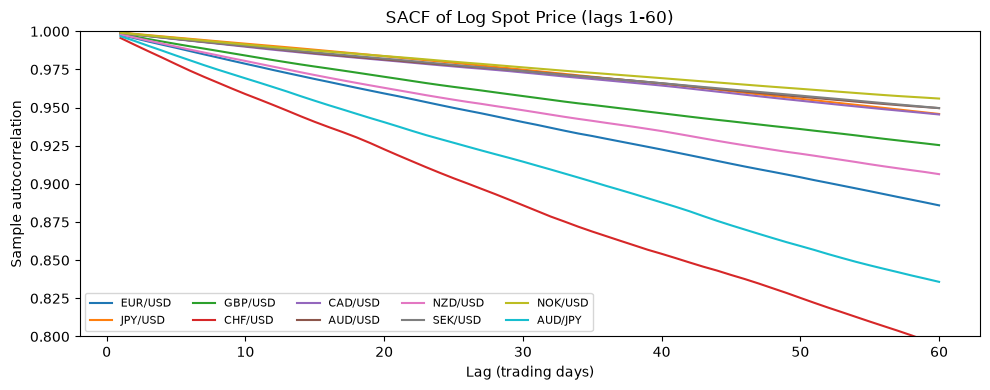

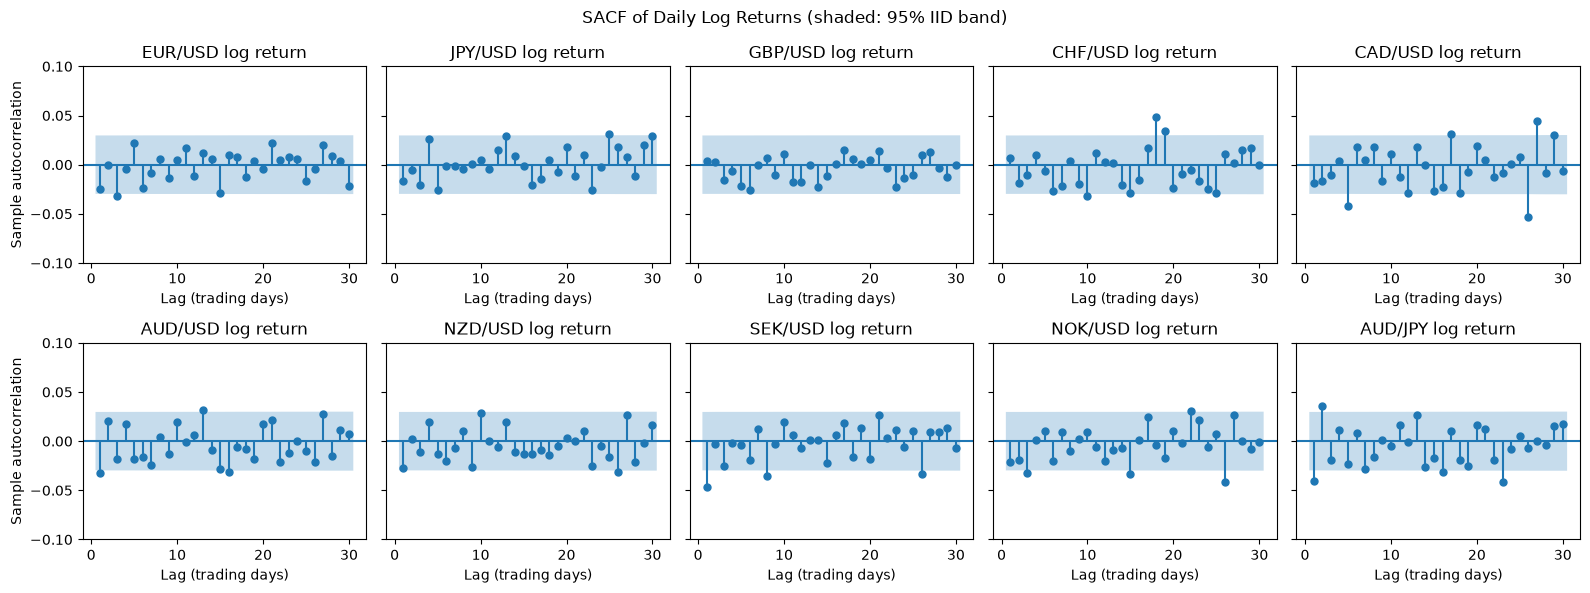

In [7]:
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf, adfuller

SERIES = CCYS + ["AUDJPY"]
LABEL = {c: f"{c}/USD" for c in CCYS} | {"AUDJPY": "AUD/JPY"}
PPY = len(carry) / ((carry.index[-1] - carry.index[0]).days / 365.25)  # obs per year (~260)

log_px = np.log(spot[SERIES])
log_ret = (log_px.diff() * 100).reindex(carry.index)
band = 1.96 / np.sqrt(len(log_ret))

# log-price SACF (all series on one axis) and log-return SACF (one panel each)
fig, ax = plt.subplots(figsize=(10, 4))
for c in SERIES:
    ax.plot(range(1, 61), acf(log_px[c], nlags=60)[1:], label=LABEL[c])
ax.set(title="SACF of Log Spot Price (lags 1-60)", xlabel="Lag (trading days)",
       ylabel="Sample autocorrelation", ylim=(0.8, 1.0))
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True)
for ax, c in zip(axes.flat, SERIES):
    plot_acf(log_ret[c], lags=30, zero=False, ax=ax, title=f"{LABEL[c]} log return",
             auto_ylims=False)
    ax.set_ylim(-0.1, 0.1)
    ax.set_xlabel("Lag (trading days)")
for ax in axes[:, 0]:
    ax.set_ylabel("Sample autocorrelation")
fig.suptitle("SACF of Daily Log Returns (shaded: 95% IID band)")
plt.tight_layout()
plt.show()

In [8]:
def adf(x):
    stat, p, *_ = adfuller(x.dropna(), autolag="AIC")
    return stat, p


rw = pd.DataFrame({
    LABEL[c]: {
        "ADF stat (log price)": adf(log_px[c])[0],
        "ADF p (log price)": adf(log_px[c])[1],
        "SACF lag 30 (log price)": acf(log_px[c], nlags=30)[30],
        "ADF stat (log return)": adf(log_ret[c])[0],
        "ADF p (log return)": adf(log_ret[c])[1],
        "Return SACF lags outside band (of 30)":
            int((np.abs(acf(log_ret[c], nlags=30)[1:]) > band).sum()),
    } for c in SERIES}).T
rw.round(3)

,ADF stat (log price),ADF p (log price),SACF lag 30 (log price),ADF stat (log return),ADF p (log return),Return SACF lags outside band (of 30)
EUR/USD,-2.468,0.124,0.941,-39.630,0.0,1.0
JPY/USD,-0.439,0.903,0.975,-67.055,0.0,1.0
GBP/USD,-2.010,0.282,0.958,-65.686,0.0,0.0
CHF/USD,-2.850,0.051,0.886,-15.017,0.0,3.0
CAD/USD,-1.293,0.633,0.973,-31.231,0.0,5.0
AUD/USD,-1.439,0.564,0.974,-68.121,0.0,3.0
NZD/USD,-1.519,0.524,0.948,-67.760,0.0,1.0
SEK/USD,-1.335,0.613,0.974,-69.119,0.0,3.0
NOK/USD,-1.496,0.535,0.976,-40.138,0.0,4.0
AUD/JPY,-1.918,0.323,0.915,-45.932,0.0,4.0


In [9]:
# CHF exception: SNB EUR/CHF floor at 1.20 (2011-09-06 to 2015-01-15)
floor = slice("2011-09-07", "2015-01-14")
eurchf = np.log(spot["EUR"] / spot["CHF"])  # log CHF per EUR
pd.DataFrame({
    "EUR/CHF, floor period": adf(eurchf.loc[floor]),
    "CHF/USD, floor period": adf(log_px["CHF"].loc[floor]),
    "EUR/CHF, full sample": adf(eurchf),
}, index=["ADF stat", "ADF p"]).T.round(3)

,ADF stat,ADF p
"EUR/CHF, floor period",-2.884,0.047
"CHF/USD, floor period",-2.066,0.258
"EUR/CHF, full sample",-2.332,0.162


**Interpretation.** None of the ten log prices rejects a unit root at the 5% level: ADF p-values range from 0.051 (CHF) to 0.90 (JPY). The log-price SACF is still between 0.89 and 0.98 at lag 30, the slow decay seen in the random-walk simulations. Every log-return series rejects a unit root (p ≈ 0). Return SACFs show only 0–5 of 30 lags outside the band (about 1.5 are expected by chance), and every coefficient is below 0.05 in absolute value (the largest is SEK at lag 1, −0.047). So every series vs USD behaves like a random walk.

**The exception is CHF.** It has the lowest lag-30 price SACF (0.886) and the borderline ADF p-value (0.051), because from 2011-09 to 2015-01 the SNB held a floor at 1.20 CHF per EUR. During the floor, log EUR/CHF **rejects** a unit root (p = 0.047) and moved only between 1.20 and 1.26, so it was a managed, mean-reverting rate rather than a random walk. CHF/USD over the same window does not reject (p = 0.26): pegging to EUR just passed on EUR/USD's random walk. The floor's removal on 2015-01-15 is the +17.6% CHF jump in the Section 1 summary.

### Section 2.2 — Mean Carry Return: Basket-Wide Significance

Module 4's IID mean test for each currency's daily carry P&L (long currency, funded in USD): $\bar z$, $\text{SE} = s/\sqrt{n}$, $t = \bar z/\text{SE}$, two-sided p-value. The mean is also split into its spot and accrual components, and the average rate differential vs USD is shown. AUD/JPY is reported below the line for continuity. Annualized figures multiply by the sample's observations per year (`PPY` ≈ 260, since Yahoo FX quotes every weekday).

In [10]:
def mean_test(x):
    n, xbar, se = len(x), x.mean(), x.std() / np.sqrt(len(x))
    t = xbar / se
    return {"mean (%/day)": xbar, "SE": se, "t-stat": t,
            "p-value": 2 * stats.norm.sf(abs(t)),
            "95% CI low": xbar - 1.96 * se, "95% CI high": xbar + 1.96 * se}


accrual = carry - log_ret  # interest-differential component of carry P&L
diff_d = pd.DataFrame({c: rates_m[c] - rates_m["USD"] for c in CCYS})
diff_d["AUDJPY"] = rates_m["AUD"] - rates_m["JPY"]
diff_d = diff_d.reindex(carry.index, method="ffill").shift(1)

mt = pd.DataFrame({c: mean_test(carry[c]) for c in SERIES}).T
mt["spot comp. (%/day)"] = log_ret.mean()
mt["accrual comp. (%/day)"] = accrual.mean()
mt["avg rate diff (% p.a.)"] = diff_d.mean()
mt["ann. mean carry (%)"] = mt["mean (%/day)"] * PPY
mt.index = [LABEL[c] for c in mt.index]
mt = pd.concat([mt.iloc[:-1].sort_values("avg rate diff (% p.a.)"), mt.iloc[-1:]])
mt.round(4)

,mean (%/day),SE,t-stat,p-value,95% CI low,95% CI high,spot comp. (%/day),accrual comp. (%/day),avg rate diff (% p.a.),ann. mean carry (%)
CHF/USD,-0.0013,0.0093,-0.1414,0.8876,-0.0196,0.0170,0.0050,-0.0063,-1.6666,-0.3437
JPY/USD,-0.0175,0.0088,-1.9971,0.0458,-0.0347,-0.0003,-0.0121,-0.0054,-1.4303,-4.5529
EUR/USD,-0.0090,0.0080,-1.1184,0.2634,-0.0247,0.0067,-0.0054,-0.0036,-0.9405,-2.3305
SEK/USD,-0.0106,0.0104,-1.0182,0.3086,-0.0310,0.0098,-0.0078,-0.0028,-0.7330,-2.7592
GBP/USD,-0.0050,0.0083,-0.6075,0.5435,-0.0213,0.0112,-0.0045,-0.0005,-0.1397,-1.3101
CAD/USD,-0.0067,0.0070,-0.9626,0.3358,-0.0204,0.0070,-0.0069,0.0002,0.0357,-1.7460
NOK/USD,-0.0104,0.0114,-0.9137,0.3609,-0.0328,0.0120,-0.0115,0.0011,0.2848,-2.7137
AUD/USD,-0.0017,0.0100,-0.1701,0.8649,-0.0213,0.0179,-0.0057,0.0040,1.0479,-0.4428
NZD/USD,-0.0011,0.0103,-0.1106,0.9120,-0.0214,0.0191,-0.0057,0.0045,1.1914,-0.2972
AUD/JPY,0.0158,0.0118,1.3361,0.1815,-0.0074,0.0390,0.0064,0.0094,2.4782,4.1120


In [11]:
nine = mt.iloc[:-1]
rho_carry = stats.spearmanr(nine["avg rate diff (% p.a.)"], nine["mean (%/day)"])
rho_spot = stats.spearmanr(nine["avg rate diff (% p.a.)"], nine["spot comp. (%/day)"])
print(f"Spearman(avg rate diff, mean carry P&L) = {rho_carry.statistic:.2f} "
      f"(p = {rho_carry.pvalue:.2f})")
print(f"Spearman(avg rate diff, mean spot return) = {rho_spot.statistic:.2f} "
      f"(p = {rho_spot.pvalue:.2f})")

Spearman(avg rate diff, mean carry P&L) = 0.38 (p = 0.31)
Spearman(avg rate diff, mean spot return) = -0.15 (p = 0.70)


**Which currencies are significant?** None of the nine shows statistically significant **positive** carry vs USD: every mean is negative and every 95% CI includes zero, except **JPY**, whose carry is significantly **negative** ($t = -2.00$, p = 0.046). AUD/JPY has a positive mean (+0.0158%/day, about +4.1% p.a.), but $t = 1.34$ (p = 0.18) is not significant either.

**The forward premium puzzle.** Across currencies, a higher rate differential goes with a higher mean carry only at the extremes. The lowest-yielding funders JPY (−1.43% p.a. vs USD) and EUR (−0.94%) have the most negative carry, and the highest-yielders AUD (+1.05%) and NZD (+1.19%) are close to zero (−0.44% and −0.30% p.a.). But CHF, the lowest-yielder (−1.67%), has near-zero carry (−0.34% p.a.) because it appreciated, and NOK (+0.28%) is among the worst (−2.71% p.a.). The rank correlation between rate differential and mean carry is only 0.38 (p = 0.31), so the relationship is weak and not robust across nine currencies.

UIP predicts high-differential currencies depreciate by the differential, which implies a strongly negative relationship between differential and spot return. The rank correlation is only −0.15 (p = 0.70), consistent with the puzzle. Even so, AUD and NZD fell about 1.5% p.a. against USD (−0.0057%/day spot component), more than their roughly 1.1% differential, because of the broad USD rally in 2011–2022. Every currency's carry vs USD is dominated by this common dollar move. That is why the Section 4 basket is dollar-neutral (long high-yielders against short low-yielders), which cancels the common dollar component.

### Section 2.3 — Bootstrap Robustness

IID bootstrap of the sample mean daily carry P&L (resampling days with replacement, $B = 1000$, seed fixed) for AUD/JPY (the lecture pair), AUD/USD (a high-yielder), and JPY/USD (the funding currency, and the only significant mean in 2.2). Resampling individual days ignores volatility clustering, so these intervals are, if anything, too narrow.

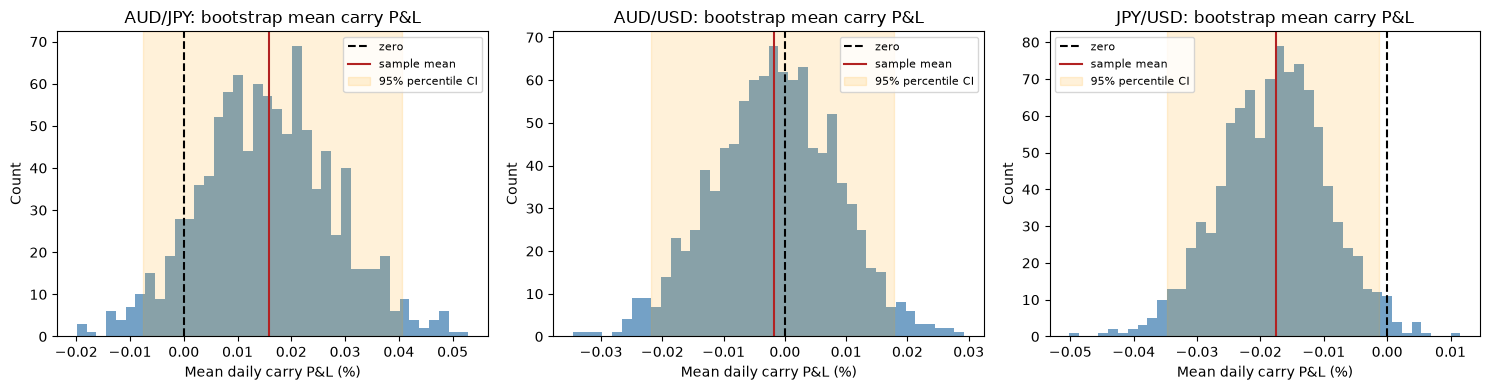

,sample mean,boot SE,2.5%,97.5%,share of resamples > 0
AUD/JPY,0.0158,0.0123,-0.0076,0.0407,0.898
AUD/USD,-0.0017,0.0100,-0.0219,0.0179,0.435
JPY/USD,-0.0175,0.0084,-0.0347,-0.0013,0.016


In [12]:
B, SEED = 1000, 4170
rng = np.random.default_rng(SEED)
boot_ccys = ["AUDJPY", "AUD", "JPY"]


def bootstrap_mean(x, B, rng):
    x = x.to_numpy()
    return x[rng.integers(0, len(x), size=(B, len(x)))].mean(axis=1)


boot = {c: bootstrap_mean(carry[c], B, rng) for c in boot_ccys}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, boot_ccys):
    lo, hi = np.percentile(boot[c], [2.5, 97.5])
    ax.hist(boot[c], bins=40, color="steelblue", alpha=0.75)
    ax.axvline(0, color="black", ls="--", label="zero")
    ax.axvline(carry[c].mean(), color="firebrick", label="sample mean")
    ax.axvspan(lo, hi, color="orange", alpha=0.15, label="95% percentile CI")
    ax.set(title=f"{LABEL[c]}: bootstrap mean carry P&L", xlabel="Mean daily carry P&L (%)",
           ylabel="Count")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame({LABEL[c]: {"sample mean": carry[c].mean(),
                         "boot SE": boot[c].std(),
                         "2.5%": np.percentile(boot[c], 2.5),
                         "97.5%": np.percentile(boot[c], 97.5),
                         "share of resamples > 0": (boot[c] > 0).mean()}
              for c in boot_ccys}).T.round(4)

**Interpretation.** The AUD/JPY finding is **fragile**. Its bootstrap distribution is centred on +0.016%/day, but the 95% percentile interval [−0.0076, +0.0407] includes zero, and 10% of resamples have a non-positive mean. Resampling alone, with no change in regime, can erase the lecture's positive carry, and treating days as IID understates that uncertainty. AUD/USD is centred on zero (43.5% of resamples above 0). JPY/USD, the funding currency, is the only one whose interval [−0.0347, −0.0013] excludes zero (98.4% of resamples below 0), so the robust part of the story is that borrowing yen was cheap. Earning a positive premium from any single pair is not robust.

## Section 3 — Revisiting Modules 5–6: Mean Predictability and Volatility per Currency

### Section 3.1 — ARMA Identification, Basket-Wide

For each of the nine currencies' daily carry P&L: ACF/PACF (lags 1–20), then an ARMA($p,q$) grid over $p, q \in \{0,\dots,3\}$ with a constant (as in Module 5), ranked by AIC and BIC. The Ljung–Box $Q(10)$ test on the carry P&L itself is a direct check for any linear mean predictability.

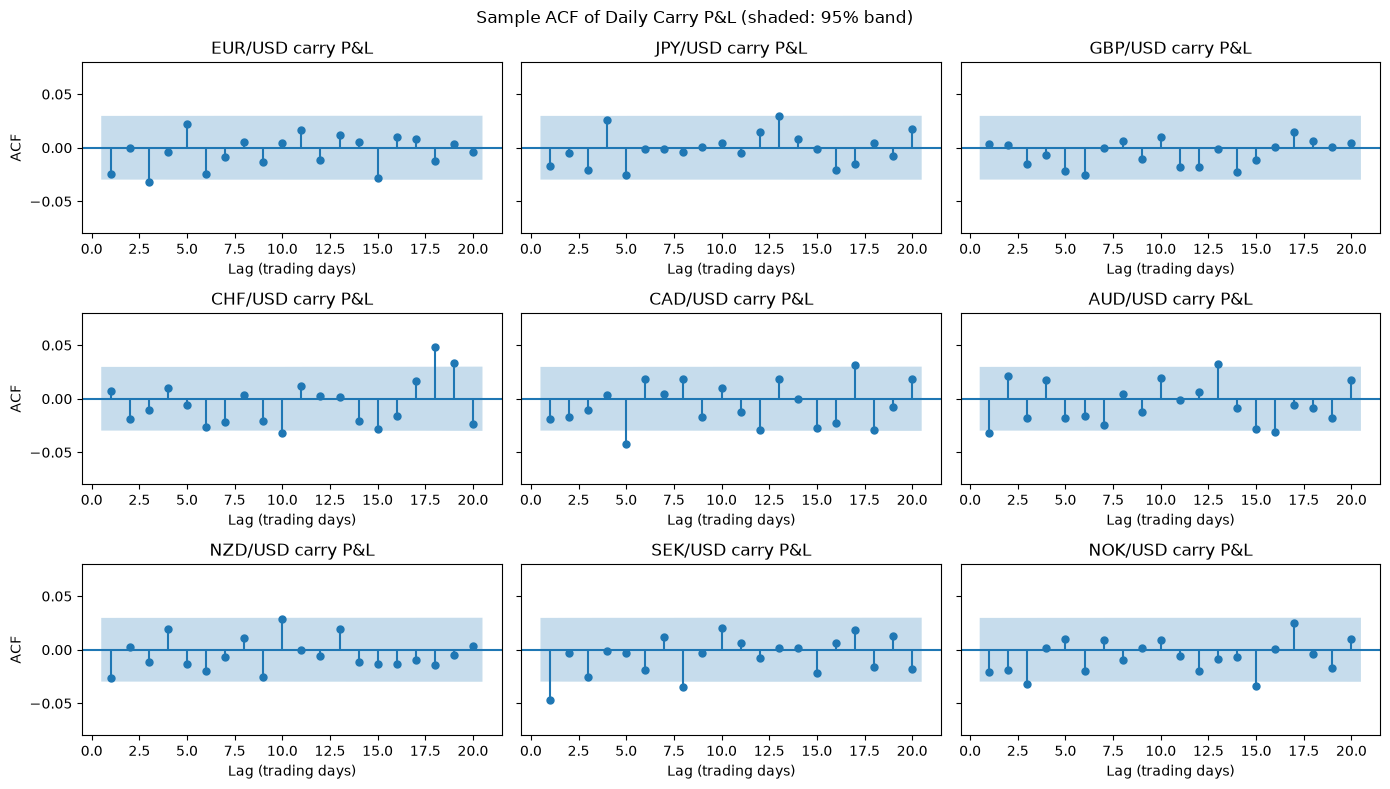

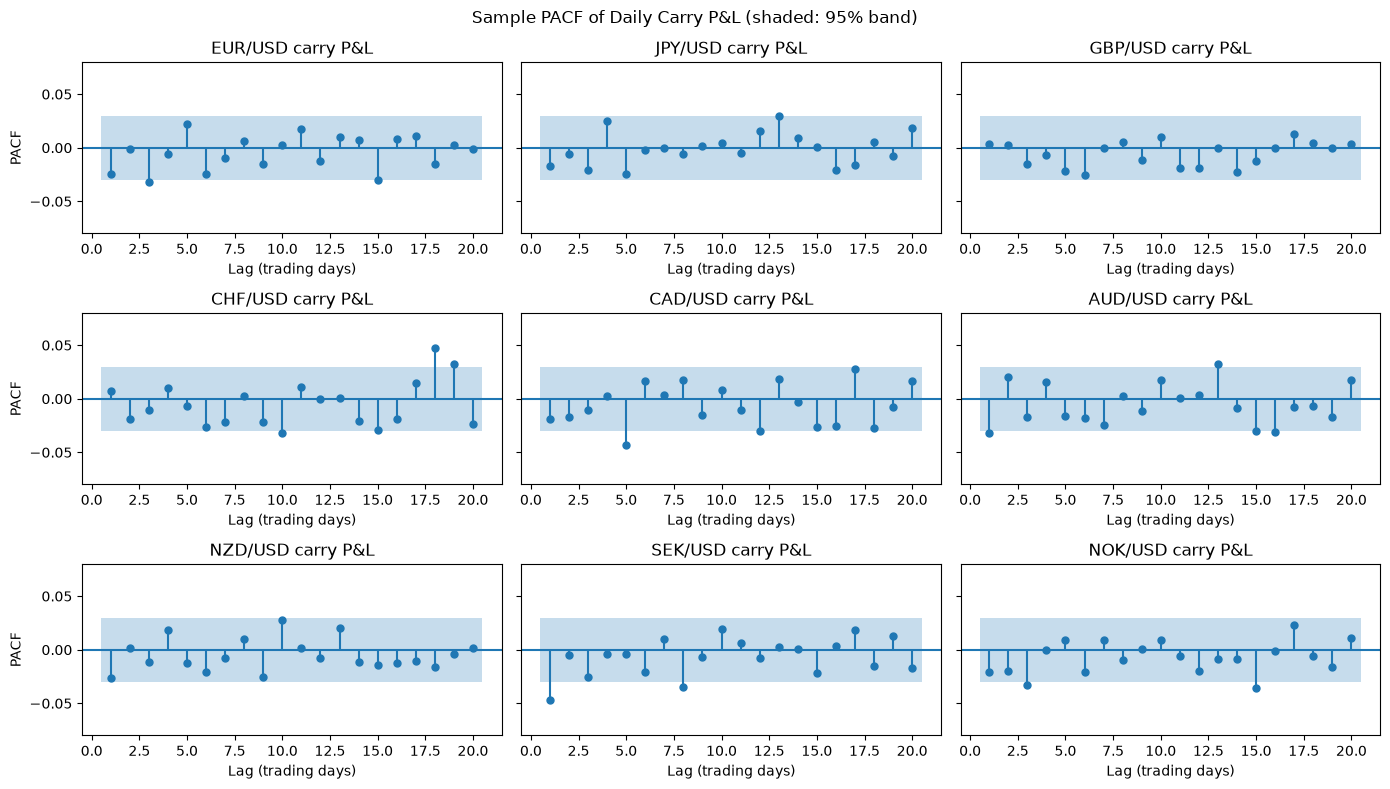

In [13]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA

for fn, name in [(plot_acf, "ACF"), (plot_pacf, "PACF")]:
    fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharey=True)
    for ax, c in zip(axes.flat, CCYS):
        fn(carry[c], lags=20, zero=False, ax=ax, title=f"{LABEL[c]} carry P&L", auto_ylims=False)
        ax.set_ylim(-0.08, 0.08)
        ax.set_xlabel("Lag (trading days)")
    for ax in axes[:, 0]:
        ax.set_ylabel(name)
    fig.suptitle(f"Sample {name} of Daily Carry P&L (shaded: 95% band)")
    plt.tight_layout()
    plt.show()

In [14]:
def arma_grid(x, max_p=3, max_q=3):
    rows = []
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                m = ARIMA(x, order=(p, 0, q), trend="c").fit()
            rows.append({"p": p, "q": q, "AIC": m.aic, "BIC": m.bic})
    return pd.DataFrame(rows)


arma_rows = {}
for c in CCYS:
    g = arma_grid(carry[c].reset_index(drop=True))
    best_aic, best_bic = g.loc[g.AIC.idxmin()], g.loc[g.BIC.idxmin()]
    base = g[(g.p == 0) & (g.q == 0)].iloc[0]
    arma_rows[LABEL[c]] = {
        "best by BIC": f"({int(best_bic.p)},{int(best_bic.q)})",
        "best by AIC": f"({int(best_aic.p)},{int(best_aic.q)})",
        "AIC gain vs (0,0)": base.AIC - best_aic.AIC,
        "Ljung-Box Q(10) p": acorr_ljungbox(carry[c], lags=[10]).lb_pvalue.iloc[0],
    }
arma_tbl = pd.DataFrame(arma_rows).T
arma_tbl.round(3)

,best by BIC,best by AIC,"AIC gain vs (0,0)",Ljung-Box Q(10) p
EUR/USD,"(0,0)","(2,3)",6.148643,0.207222
JPY/USD,"(0,0)","(0,0)",0.0,0.535978
GBP/USD,"(0,0)","(0,0)",0.0,0.685985
CHF/USD,"(0,0)","(1,3)",4.241206,0.157208
CAD/USD,"(0,0)","(3,3)",8.360959,0.107744
AUD/USD,"(0,0)","(1,1)",5.387036,0.085155
NZD/USD,"(0,0)","(2,3)",9.560691,0.132774
SEK/USD,"(0,1)","(0,1)",7.711281,0.015678
NOK/USD,"(0,0)","(3,3)",4.073661,0.326901


**Interpretation.** The lecture's "no meaningful mean predictability" finding holds for 8 of 9 currencies. BIC selects ARMA(0,0), i.e. white noise around a constant, for all except SEK, and Ljung–Box $Q(10)$ does not reject for those eight (p = 0.09–0.69). AIC picks larger models for EUR, CHF, CAD, AUD, NZD and NOK, but its gains over (0,0) are only 4–10 points at $n = 4351$. That is the overfitting expected from AIC's light penalty, and BIC rejects them. The ACF/PACF panels agree: nearly all spikes are inside the band.

**Outlier: SEK.** Both criteria choose MA(1), with $\hat\theta_1 = -0.048$ (p < 0.001), and $Q(10)$ rejects (p = 0.016). The effect is tiny: an MA coefficient of −0.048 explains about 0.2% of daily variance. It is consistent with slight bid–ask bounce or noise in closing prices for a less liquid pair, not an exploitable edge after costs. The basket therefore needs no mean model for any leg; each leg's expected return is simply its carry.

### Section 3.2 — GARCH Fitting, Basket-Wide

GARCH(1,1) with a constant mean is fitted to each currency's daily carry P&L (%) with both Normal and Student-$t$ innovations (`arch`, as in Module 6). The table reports $\hat\alpha_1$, $\hat\beta_1$ and persistence $\hat\alpha_1+\hat\beta_1$ for each distribution, the volatility half-life $\ln 0.5/\ln(\hat\alpha_1+\hat\beta_1)$ in days, and the AIC/BIC winner. The last columns report Ljung–Box $Q(10)$ on the squared raw carry P&L, which tests for clustering, and on the squared standardized residuals of the winning fit, which tests whether the model absorbed it. The Student-$t$ fits are kept in `garch_t` for Sections 4–5.

In [15]:
from arch import arch_model


def fit_garch(x, dist):
    return arch_model(x, mean="Constant", vol="GARCH", p=1, q=1, dist=dist).fit(disp="off")


garch_n, garch_t, g_rows = {}, {}, {}
for c in CCYS:
    garch_n[c], garch_t[c] = fit_garch(carry[c], "normal"), fit_garch(carry[c], "t")
    row = {}
    for tag, r in [("N", garch_n[c]), ("t", garch_t[c])]:
        a, b = r.params["alpha[1]"], r.params["beta[1]"]
        row |= {f"alpha1 ({tag})": a, f"beta1 ({tag})": b, f"persist. ({tag})": a + b}
    row["nu (t)"] = garch_t[c].params["nu"]
    row["half-life, days (t)"] = np.log(0.5) / np.log(row["persist. (t)"])
    row["AIC winner"] = "t" if garch_t[c].aic < garch_n[c].aic else "Normal"
    row["BIC winner"] = "t" if garch_t[c].bic < garch_n[c].bic else "Normal"
    win = garch_t[c] if row["BIC winner"] == "t" else garch_n[c]
    row["LB Q(10) p, raw sq."] = acorr_ljungbox(carry[c] ** 2, lags=[10]).lb_pvalue.iloc[0]
    row["LB Q(10) p, std. resid sq."] = acorr_ljungbox(win.std_resid ** 2, lags=[10]).lb_pvalue.iloc[0]
    g_rows[LABEL[c]] = row
garch_tbl = pd.DataFrame(g_rows).T
garch_tbl.round(3)

,alpha1 (N),beta1 (N),persist. (N),alpha1 (t),beta1 (t),persist. (t),nu (t),"half-life, days (t)",AIC winner,BIC winner,"LB Q(10) p, raw sq.","LB Q(10) p, std. resid sq."
EUR/USD,0.035815,0.959807,0.995622,0.036733,0.961061,0.997794,7.359681,313.865148,t,t,0.0,0.459716
JPY/USD,0.058618,0.927135,0.985753,0.068123,0.924268,0.99239,5.085998,90.73868,t,t,0.0,0.843168
GBP/USD,0.059875,0.925455,0.98533,0.039006,0.950892,0.989899,6.793172,68.272491,t,t,0.0,0.050009
CHF/USD,0.04704,0.95296,1.0,0.03259,0.954312,0.986902,6.012946,52.5727,t,t,0.884126,1.0
CAD/USD,0.043573,0.949038,0.992611,0.041719,0.953507,0.995225,8.166947,144.826271,t,t,0.0,0.435809
AUD/USD,0.051569,0.936827,0.988396,0.046087,0.943925,0.990012,10.349324,69.048562,t,t,0.0,0.47405
NZD/USD,0.04291,0.945444,0.988354,0.038748,0.950603,0.989351,12.408911,64.745046,t,t,0.0,0.079495
SEK/USD,0.032738,0.958412,0.991149,0.030936,0.963658,0.994594,8.591446,127.872134,t,t,0.0,0.412618
NOK/USD,0.050983,0.927266,0.978249,0.033031,0.962437,0.995468,7.184857,152.602822,t,t,0.0,0.0


In [16]:
# CHF: the SNB floor-removal day (17.6%, dated 2015-01-16 by Yahoo) dominates the squared series
chf_ex = carry["CHF"].drop(pd.Timestamp("2015-01-16"))
print("CHF LB Q(10) p on squared carry P&L, excluding 2015-01-16:",
      f"{acorr_ljungbox(chf_ex ** 2, lags=[10]).lb_pvalue.iloc[0]:.1e}")

CHF LB Q(10) p on squared carry P&L, excluding 2015-01-16: 1.5e-12


**Interpretation.** Student-$t$ innovations win on both AIC and BIC for all nine currencies. The fitted $\hat\nu$ ranges from 5.1 (JPY) to 12.4 (NZD), so every leg has fat tails, and JPY, the funding currency, has the fattest. All nine show volatility clustering. Squared carry P&L rejects Ljung–Box at p ≈ 0 for eight currencies. CHF's raw p = 0.88 is caused by the single 17.6% floor-removal day; without it, CHF rejects at p ≈ $10^{-12}$.

The strength of clustering differs:

- **Most persistent:** EUR, with $\hat\alpha_1+\hat\beta_1 = 0.998$ and a half-life of about 314 days. NOK, CAD and SEK are close behind (half-lives 128–153 days).
- **Fastest-reacting:** JPY has the largest $\hat\alpha_1$ (0.068), so its volatility jumps most after a shock, which is consistent with yen spikes during risk-off episodes. AUD's $\hat\alpha_1$ is 0.046.
- **Shortest-lived:** CHF, GBP, AUD and NZD have half-lives of 53–69 days, so their shocks fade fastest.
- **Near-IGARCH:** CHF's Normal fit sits on the boundary (persistence = 1.000) because the Normal cannot absorb the 2015 jump. The $t$ fit absorbs it (0.987).

**Residual check.** The $t$-GARCH standardized residuals pass Ljung–Box for seven currencies (p = 0.08–1.0), with GBP borderline (0.050). NOK fails (p ≈ 0): GARCH(1,1) leaves NOK volatility dependence unexplained, likely from oil-driven regime shifts and the 2020 stress period. So one model (GARCH(1,1)-$t$) works reasonably for every leg except NOK, whose vol forecasts should be trusted less.

### Section 3.3 — The Fama Regression, Basket-Wide

$$\Delta s_{t+1} = \alpha + \beta\,(i_{\text{foreign},t} - i_{\text{USD},t}) + \varepsilon_{t+1}$$

**Sign convention.** For UIP to imply $\beta = 1$ in this equation, $s_t$ must be the log price of **USD in foreign currency** (foreign per USD), so that $\Delta s>0$ means USD appreciates. That is the inverse of the storage convention, so $\Delta s_{t+1} = -100\,\Delta\ln S_{i,t+1}$ (USD per foreign), and nothing else changes. Under UIP, a positive differential means USD is expected to appreciate by exactly that differential.

**Frequency.** Monthly and non-overlapping, to match the monthly rate data. $\Delta s_{t+1}$ is the log change (%) in month-end spot from month $t$ to $t+1$, and the regressor is month $t$'s rate differential converted to a monthly rate (annual %/12), so both sides are in % per month. Standard errors are HAC (Newey–West, 3 lags). $t$-statistics are reported against both $\beta=0$ and the UIP value $\beta=1$.

In [17]:
import statsmodels.api as sm

spot_m = spot[CCYS].resample("ME").last()
ds_m = -np.log(spot_m).diff().shift(-1) * 100            # month t -> t+1, USD appreciation (%)
diff_m = (rates_m[CCYS].sub(rates_m["USD"], axis=0) / 12)
diff_m.index = diff_m.index + pd.offsets.MonthEnd(0)     # month-t rate aligned to month-t end

fama = {}
for c in CCYS:
    d = ds_m[c].rename("ds").to_frame().join(diff_m[c].rename("diff"), how="inner").dropna()
    r = sm.OLS(d["ds"], sm.add_constant(d["diff"])).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
    b, se = r.params["diff"], r.bse["diff"]
    fama[LABEL[c]] = {"beta_hat": b, "SE (HAC)": se, "t (beta=0)": b / se,
                      "t (beta=1)": (b - 1) / se, "R2": r.rsquared, "n (months)": int(r.nobs)}
fama_tbl = pd.DataFrame(fama).T
fama_tbl.round(3)

,beta_hat,SE (HAC),t (beta=0),t (beta=1),R2,n (months)
EUR/USD,1.994,1.940,1.028,0.512,0.005,200.0
JPY/USD,0.434,1.353,0.321,-0.418,0.001,200.0
GBP/USD,1.271,3.286,0.387,0.083,0.001,200.0
CHF/USD,0.462,1.483,0.312,-0.363,0.001,200.0
CAD/USD,2.594,2.089,1.242,0.763,0.005,200.0
AUD/USD,-0.487,1.391,-0.350,-1.069,0.001,200.0
NZD/USD,0.131,1.673,0.079,-0.519,0.000,200.0
SEK/USD,-0.214,1.784,-0.120,-0.680,0.000,200.0
NOK/USD,-0.174,2.090,-0.083,-0.562,0.000,200.0


**Interpretation.** UIP ($\beta=1$) is not rejected for any currency: every $|t_{\beta=1}| < 1.1$. The estimates are very imprecise, with HAC SEs of 1.35–3.29, because the rate differential barely moved during the 2010–2021 near-zero-rate era, which leaves little regressor variation ($R^2 \le 0.5\%$). Within that noise, the puzzle appears for **some currencies, not all**. Six of nine have $\hat\beta < 1$: JPY 0.43, CHF 0.46, NZD 0.13, and three negative ($\hat\beta < 0$), AUD −0.49, SEK −0.21 and NOK −0.17. EUR (1.99), GBP (1.27) and CAD (2.59) have $\hat\beta > 1$. The strongest puzzle evidence is in the classic carry currencies (the high-yielders AUD and NZD, and the NOK and SEK legs), which is where a carry basket takes its positions.

**Why a basket should earn positive expected P&L.** The expected excess return of a long position in currency $i$ is $(i_i - i_{\text{USD}}) - E[\Delta s] = (1-\beta)(i_i - i_{\text{USD}}) - \alpha$. Whenever $\beta < 1$, a higher differential means a higher expected return. Going long the highest-differential and short the lowest-differential currencies therefore earns $(1-\beta)$ times the cross-sectional spread in rates, and the common USD term $\alpha$ cancels in a dollar-neutral basket. With six of nine $\hat\beta$ below one, the table supports that premise, but only weakly, since no single estimate is significant. The positive expected P&L is a hypothesis for Sections 4–5 to test, not something this table proves.